In [28]:
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd


def load_ucr_arff(path: Path) -> np.ndarray:
    """UCR ARFF 파일에서 @data 이후 숫자 행만 읽어 ndarray로 반환"""
    text = path.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "@data":
            data_start = i + 1
            break

    if data_start is None:
        raise ValueError(f"@data 섹션을 찾을 수 없습니다: {path}")

    data_lines = [
        line.strip()
        for line in lines[data_start:]
        if line.strip() and not line.strip().startswith("%")
    ]

    return np.loadtxt(StringIO("\n".join(data_lines)), delimiter=",", dtype=np.float32)


# 커널 환경(로컬/Colab)에 따라 dataset 경로 자동 판별

def resolve_data_dir() -> Path:
    train_name = "FordA_TRAIN.arff"
    test_name = "FordA_TEST.arff"

    def has_both_files(d: Path) -> bool:
        return d.is_dir() and (d / train_name).exists() and (d / test_name).exists()

    # Colab이면 Drive 자동 마운트 시도
    try:
        from google.colab import drive  # type: ignore

        if not Path("/content/drive").exists():
            drive.mount("/content/drive")
    except Exception:
        pass

    candidate_dirs = [
        Path("./dataset").resolve(),
        Path("../dataset").resolve(),
        Path("/content/dataset"),
        Path("/content/ML_Training/dataset"),
        Path("/content/drive/MyDrive/dataset"),
        Path("/content/drive/MyDrive/ML_Training/dataset"),
        Path("/Users/erickim/Documents/ML_Training/dataset"),
    ]

    for d in candidate_dirs:
        if has_both_files(d):
            return d

    # Drive 하위에서 파일명을 기준으로 한 번 더 탐색
    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        for p in drive_root.rglob(train_name):
            parent = p.parent
            if (parent / test_name).exists():
                return parent

    raise FileNotFoundError(
        "dataset 폴더를 찾지 못했습니다. "
        f"cwd={Path.cwd()} | 확인한 경로={ [str(d) for d in candidate_dirs] }\n"
        "Colab이면 Drive를 마운트하고, FordA_TRAIN.arff/FordA_TEST.arff를 같은 폴더에 두세요."
    )


data_dir = resolve_data_dir()

train_path = data_dir / "FordA_TRAIN.arff"
test_path = data_dir / "FordA_TEST.arff"

if not (train_path.exists() and test_path.exists()):
    train_candidates = sorted(data_dir.glob("*_TRAIN.arff"))
    test_candidates = sorted(data_dir.glob("*_TEST.arff"))

    if not train_candidates or not test_candidates:
        arff_files = [p.name for p in sorted(data_dir.glob("*.arff"))]
        raise FileNotFoundError(
            "dataset 폴더에서 train/test ARFF 파일을 찾지 못했습니다. "
            f"data_dir={data_dir}, 현재 ARFF 파일: {arff_files}"
        )

    train_path = train_candidates[0]
    test_path = test_candidates[0]

train_data = load_ucr_arff(train_path)
test_data = load_ucr_arff(test_path)

# 마지막 열: label(target), 앞 열: 시계열 값
X_train, y_train = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

# 최종 DataFrame 생성
feature_cols = [f"x_{i}" for i in range(1, X_train.shape[1] + 1)]
train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df["target"] = y_train.astype(np.int8)

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df["target"] = y_test.astype(np.int8)

# train/test 합친 전체 데이터프레임
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print("Data dir:", data_dir)
print("Train file:", train_path.name)
print("Test file :", test_path.name)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)
print("df      :", df.shape)

Data dir: /Users/erickim/Documents/ML_Training/dataset
Train file: FordA_TRAIN.arff
Test file : FordA_TEST.arff
Train: (3601, 500) (3601,)
Test : (1320, 500) (1320,)
train_df: (3601, 501)
test_df : (1320, 501)
df      : (4921, 501)


In [29]:
print(train_df.columns)
print(test_df.columns)

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_492', 'x_493', 'x_494', 'x_495', 'x_496', 'x_497', 'x_498', 'x_499',
       'x_500', 'target'],
      dtype='object', length=501)
Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_492', 'x_493', 'x_494', 'x_495', 'x_496', 'x_497', 'x_498', 'x_499',
       'x_500', 'target'],
      dtype='object', length=501)


In [30]:
print(df.columns)

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       ...
       'x_492', 'x_493', 'x_494', 'x_495', 'x_496', 'x_497', 'x_498', 'x_499',
       'x_500', 'target'],
      dtype='object', length=501)


In [5]:
import duckdb


def esql(sql, conn=None):
    if conn is None:
        conn = duckdb.connect()

    return conn.execute(sql).df()

In [6]:
esql("select target, count(*) from df group by target")


,target,count_star()
0,-1,2527
1,1,2394


In [31]:
from pycaret.classification import setup

clf1 = setup(df, target="target", session_id=123)

,Description,Value
0,Session id,123
1,Target,target
2,Target type,Binary
3,Target mapping,"-1: 0, 1: 1"
4,Original data shape,"(4921, 501)"
5,Transformed data shape,"(4921, 501)"
6,Transformed train set shape,"(3444, 501)"
7,Transformed test set shape,"(1477, 501)"
8,Numeric features,500
9,Preprocess,True


In [34]:
clf1.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [32]:
best = clf1.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.8435,0.9220,0.8435,0.8521,0.8421,0.6854,0.6946,0.3070
lightgbm,Light Gradient Boosting Machine,0.7805,0.8620,0.7805,0.7809,0.7805,0.5609,0.5611,1.6050
rf,Random Forest Classifier,0.7422,0.8200,0.7422,0.7435,0.7415,0.4831,0.4849,1.1160
et,Extra Trees Classifier,0.7419,0.8186,0.7419,0.7424,0.7415,0.4828,0.4836,0.3020
knn,K Neighbors Classifier,0.7163,0.7798,0.7163,0.7179,0.7153,0.4309,0.4331,0.1260
gbc,Gradient Boosting Classifier,0.6487,0.6956,0.6487,0.6488,0.6481,0.2959,0.2965,10.7730
dt,Decision Tree Classifier,0.5836,0.5832,0.5836,0.5837,0.5834,0.1665,0.1666,0.4770
ada,Ada Boost Classifier,0.5215,0.5208,0.5215,0.5210,0.5198,0.0405,0.0409,2.2620
lda,Linear Discriminant Analysis,0.5148,0.4923,0.5148,0.5177,0.5102,0.0343,0.0345,0.2000
dummy,Dummy Classifier,0.5136,0.5000,0.5136,0.2638,0.3486,0.0000,0.0000,0.0540


In [36]:
compare_tree_models = clf1.compare_models(include = ['dt', 'lightgbm'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7805,0.8620,0.7805,0.7809,0.7805,0.5609,0.5611,1.9750
dt,Decision Tree Classifier,0.5836,0.5832,0.5836,0.5837,0.5834,0.1665,0.1666,0.5550


In [37]:
best_recall_models_top3 = clf1.compare_models(sort = 'Recall', n_select = 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.8435,0.9220,0.8435,0.8521,0.8421,0.6854,0.6946,0.3280
lightgbm,Light Gradient Boosting Machine,0.7805,0.8620,0.7805,0.7809,0.7805,0.5609,0.5611,1.5610
rf,Random Forest Classifier,0.7422,0.8200,0.7422,0.7435,0.7415,0.4831,0.4849,1.0580
et,Extra Trees Classifier,0.7419,0.8186,0.7419,0.7424,0.7415,0.4828,0.4836,0.3010
knn,K Neighbors Classifier,0.7163,0.7798,0.7163,0.7179,0.7153,0.4309,0.4331,0.1080
gbc,Gradient Boosting Classifier,0.6487,0.6956,0.6487,0.6488,0.6481,0.2959,0.2965,11.3340
dt,Decision Tree Classifier,0.5836,0.5832,0.5836,0.5837,0.5834,0.1665,0.1666,0.5100
ada,Ada Boost Classifier,0.5215,0.5208,0.5215,0.5210,0.5198,0.0405,0.0409,2.0960
lda,Linear Discriminant Analysis,0.5148,0.4923,0.5148,0.5177,0.5102,0.0343,0.0345,0.1800
dummy,Dummy Classifier,0.5136,0.5000,0.5136,0.2638,0.3486,0.0000,0.0000,0.0810


In [16]:
lightgbm1=clf1.create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8029,0.8797,0.8029,0.8029,0.8029,0.6055,0.6055
1,0.7710,0.8574,0.7710,0.7717,0.7710,0.5422,0.5426
2,0.7536,0.8419,0.7536,0.7546,0.7536,0.5076,0.5083
3,0.8116,0.8790,0.8116,0.8120,0.8116,0.6232,0.6235
4,0.7791,0.8674,0.7791,0.7793,0.7791,0.5581,0.5583
5,0.7849,0.8717,0.7849,0.7850,0.7849,0.5695,0.5696
6,0.7703,0.8496,0.7703,0.7711,0.7704,0.5409,0.5413
7,0.7703,0.8474,0.7703,0.7708,0.7704,0.5407,0.5409
8,0.7703,0.8541,0.7703,0.7705,0.7701,0.5398,0.5402


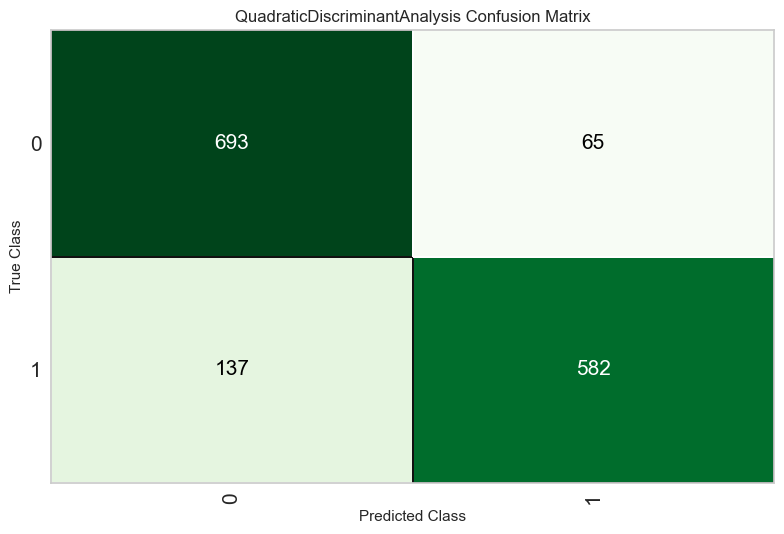

In [13]:
clf1.plot_model(best, plot = 'confusion_matrix')

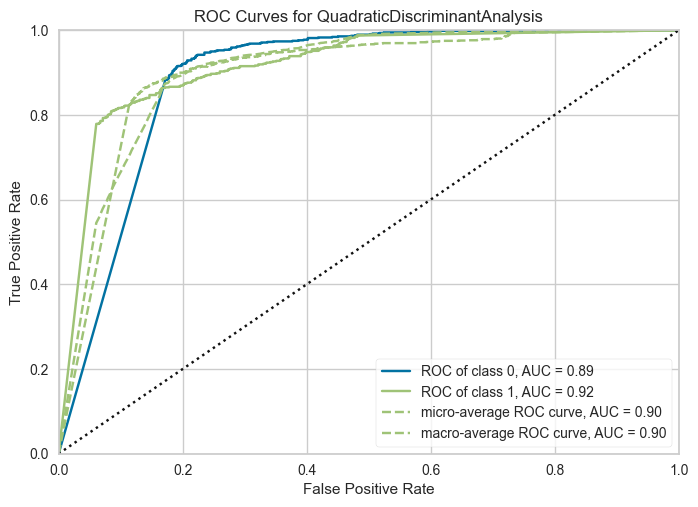

In [14]:
clf1.plot_model(best, plot = 'auc')

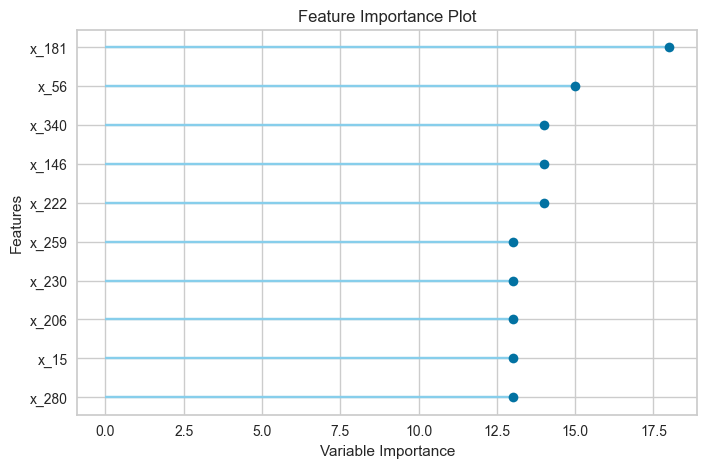

In [17]:
# plot feature importance
clf1.plot_model(lightgbm1, plot = 'feature')

In [20]:
i = pd.DataFrame({
    "feature": clf1.get_config("X_train").columns,
    "importance": lightgbm1.feature_importances_
}).sort_values("importance", ascending=False)
print(i)


    feature  importance
180   x_181          18
55     x_56          15
221   x_222          14
145   x_146          14
339   x_340          14
..      ...         ...
320   x_321           0
224   x_225           0
295   x_296           0
407   x_408           0
331   x_332           0

[500 rows x 2 columns]


In [23]:
# predict on test set
holdout_pred = clf1.predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Quadratic Discriminant Analysis,0.8632,0.9158,0.8632,0.8664,0.8627,0.7256,0.7291


In [27]:
# show predictions df
holdout_pred[["target", "prediction_label","prediction_score"]].head(10)

,target,prediction_label,prediction_score
631,1,1,1.0
4751,-1,-1,1.0
1271,-1,-1,1.0
2869,1,1,1.0
1417,1,1,1.0
371,-1,-1,1.0
4790,-1,-1,1.0
3976,-1,-1,1.0
2412,-1,-1,1.0
3838,-1,-1,1.0
